# DeepFM for MS MARCO Ranking

Load features from `marco_df_new_feats.pkl` (11 dense features including **idf_weighted_overlap** and **first_query_term_position_norm**), prepare data, and train a DeepFM model for relevance ranking.

---

## Contents

1. **Load feature data** — Load `marco_df_new_feats.pkl` and inspect columns/labels.
2. **Feature columns and split** — Define 11 dense features, query-level train/val/test split, scaling, and ranking metrics (MRR@k, NDCG@k).
3. **DeepFM model** — Build and train DeepFM (linear + FM + DNN), then evaluate on val/test.
4. **Sensitivity analysis** — Hyperparameter sensitivity (DNN size, dropout), feature ablation (leave-one-out), and permutation importance.
5. **Removing unhelpful features** — Retrain with a reduced feature set based on permutation analysis.
6. **Class imbalance** — Optional oversampling of positive class; impact on metrics.

### Setup — Imports and dependencies

In [71]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from deepctr_torch.inputs import DenseFeat, get_feature_names
from deepctr_torch.models import DeepFM


## 1. Load feature data from `marco_df_new_feats.pkl`

This file contains one row per query–passage pair with engineered features (including **idf_weighted_overlap** and **first_query_term_position_norm**) and binary label.

In [72]:
# Load the feature dataframe from marco_df_new_feats.pkl (includes idf_weighted_overlap, first_query_term_position_norm)
df = pd.read_pickle("marco_df_new_feats.pkl")

print(f"Loaded shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head()

Loaded shape: (54281, 20)
Columns: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers', 'passage_text', 'is_selected', 'label', 'query_length', 'passage_length', 'length_ratio', 'exact_match', 'query_term_coverage', 'jaccard_similarity', 'tfidf_cosine_sim', 'bm25_score', 'passage_position', 'idf_weighted_overlap', 'first_query_term_position_norm']
Label distribution:
label
0    48482
1     5799
Name: count, dtype: int64


,answers,passages,query,query_id,query_type,wellFormedAnswers,passage_text,is_selected,label,query_length,passage_length,length_ratio,exact_match,query_term_coverage,jaccard_similarity,tfidf_cosine_sim,bm25_score,passage_position,idf_weighted_overlap,first_query_term_position_norm
0,[Backordered means that the company would norm...,"{'is_selected': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]...",what does backordered mean,1084185,DESCRIPTION,[],Best Answer: I did not agree with the comment ...,0,0,4,32,0.121212,0,0.25,0.032258,0.178236,12.01355,0,9.985657,0.34375
1,[Backordered means that the company would norm...,"{'is_selected': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]...",what does backordered mean,1084185,DESCRIPTION,[],a store generally has a front and back portion...,0,0,4,46,0.085106,0,0.00,0.000000,0.000000,0.00000,1,0.000000,1.00000
2,[Backordered means that the company would norm...,"{'is_selected': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]...",what does backordered mean,1084185,DESCRIPTION,[],Backordered: This means that the company would...,1,1,4,69,0.057143,0,0.00,0.000000,0.108672,0.00000,2,0.000000,1.00000
3,[Backordered means that the company would norm...,"{'is_selected': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]...",what does backordered mean,1084185,DESCRIPTION,[],A domain backorder is service that helps one t...,0,0,4,40,0.097561,0,0.00,0.000000,0.000000,0.00000,3,0.000000,1.00000
4,[Backordered means that the company would norm...,"{'is_selected': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]...",what does backordered mean,1084185,DESCRIPTION,[],Backordered: This means that the company would...,0,0,4,64,0.061538,0,0.00,0.000000,0.119871,0.00000,4,0.000000,1.00000


## 2. Feature columns and query-level split

Use the same 11 dense features as in feature engineering (original 9 plus **idf_weighted_overlap** and **first_query_term_position_norm**). Split by **query_id** so all passages for a query stay in one split (avoids leakage).

In [73]:
FEATURE_COLS = [
    "query_length", "passage_length", "length_ratio",
    "exact_match", "query_term_coverage", "jaccard_similarity",
    "tfidf_cosine_sim", "bm25_score", "passage_position",
    "idf_weighted_overlap", "first_query_term_position_norm",
]
TARGET = "label"

# Ensure we only use rows that have all features
df = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f"Rows after dropna: {len(df):,}")

# Query-level split: 70% train, 15% val, 15% test
unique_qids = df["query_id"].unique()
train_qids, rest_qids = train_test_split(unique_qids, test_size=0.30, random_state=42)
val_qids, test_qids = train_test_split(rest_qids, test_size=0.50, random_state=42)

train_df = df[df["query_id"].isin(train_qids)].reset_index(drop=True)
val_df = df[df["query_id"].isin(val_qids)].reset_index(drop=True)
test_df = df[df["query_id"].isin(test_qids)].reset_index(drop=True)

print(f"Train: {len(train_df):,} rows ({len(train_qids):,} queries)")
print(f"Val:   {len(val_df):,} rows ({len(val_qids):,} queries)")
print(f"Test:  {len(test_df):,} rows ({len(test_qids):,} queries)")

Rows after dropna: 54,281
Train: 37,986 rows (3,804 queries)
Val:   8,149 rows (815 queries)
Test:  8,146 rows (816 queries)


### 2.1 Scale dense features to [0, 1]

Fit `MinMaxScaler` on train only, then transform train/val/test to avoid leakage.

In [74]:
# Scale dense features to [0, 1] (fit on train only)
scaler = MinMaxScaler(feature_range=(0, 1))
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
val_df[FEATURE_COLS] = scaler.transform(val_df[FEATURE_COLS])
test_df[FEATURE_COLS] = scaler.transform(test_df[FEATURE_COLS])
print("Features scaled to [0, 1].")

Features scaled to [0, 1].


### 2.2 Ranking metrics (MRR@k, NDCG@k)

Query-level MRR and NDCG for evaluating ranking quality; used later for val/test reporting.

In [75]:
# Ranking metrics: MRR and NDCG@k (query-level, then averaged)
def _dcg(relevances, k):
    """DCG@k; relevances is 1-d array in ranked order (binary relevance)."""
    rel = np.asarray(relevances)[:k]
    if len(rel) == 0:
        return 0.0
    gains = np.power(2, rel) - 1
    positions = np.arange(1, len(gains) + 1, dtype=float)
    return np.sum(gains / np.log2(positions + 1))

def mrr_at_k(labels, scores, query_ids, k=10):
    """Mean Reciprocal Rank: 1/rank of first relevant doc per query (1-indexed), then mean."""
    labels = np.asarray(labels).flatten()
    scores = np.asarray(scores).flatten()
    query_ids = np.asarray(query_ids).flatten()
    df = pd.DataFrame({"query_id": query_ids, "label": labels, "score": scores})
    rr_list = []
    for _, g in df.groupby("query_id"):
        g = g.sort_values("score", ascending=False).reset_index(drop=True)
        rel_ranks = np.where(g["label"].values == 1)[0]  # 0-indexed
        if len(rel_ranks) == 0:
            rr_list.append(0.0)
        else:
            first_rank_1based = int(rel_ranks[0]) + 1
            rr_list.append(1.0 / first_rank_1based if first_rank_1based <= k else 0.0)
    return np.mean(rr_list) if rr_list else 0.0

def ndcg_at_k(labels, scores, query_ids, k=10):
    """NDCG@k with binary relevance; averaged over queries."""
    labels = np.asarray(labels).flatten()
    scores = np.asarray(scores).flatten()
    query_ids = np.asarray(query_ids).flatten()
    df = pd.DataFrame({"query_id": query_ids, "label": labels, "score": scores})
    ndcg_list = []
    for _, g in df.groupby("query_id"):
        rel = g["label"].values
        ideal_rel = np.sort(rel)[::-1]
        ideal_dcg = _dcg(ideal_rel, k)
        if ideal_dcg == 0:
            ndcg_list.append(0.0)
            continue
        pred_order = np.argsort(-g["score"].values)
        dcg_val = _dcg(rel[pred_order], k)
        ndcg_list.append(dcg_val / ideal_dcg)
    return np.mean(ndcg_list) if ndcg_list else 0.0

## 3. DeepFM model

All features are dense (continuous). Define feature columns and build the model with `deepctr-torch`.

- **3.1** Prepare model inputs (feature columns, train/val/test arrays).
- **3.2** Build and compile DeepFM (device, linear + DNN columns, binary task).
- **3.3** Train with validation split.
- **3.4** Evaluate on validation and test (accuracy, MRR@10, NDCG@10).

In [76]:
# All 11 features are dense (one dimension each)
dense_feature_columns = [DenseFeat(feat, 1) for feat in FEATURE_COLS]
linear_feature_columns = dense_feature_columns
dnn_feature_columns = dense_feature_columns

feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Model input: dict of feature name -> array
train_model_input = {name: train_df[name].values for name in feature_names}
val_model_input = {name: val_df[name].values for name in feature_names}
test_model_input = {name: test_df[name].values for name in feature_names}

y_train = train_df[TARGET].values
y_val = val_df[TARGET].values
y_test = test_df[TARGET].values

In [77]:
# Device and model
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task="binary",
    device=device,
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])

Using device: cpu


In [78]:
# Train (use 15% of train for validation during training)
history = model.fit(
    train_model_input,
    y_train,
    batch_size=256,
    epochs=10,
    verbose=2,
    validation_split=0.15,
)

cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
Epoch 1/10
1s - loss:  0.3683 - binary_crossentropy:  0.3678 - val_binary_crossentropy:  0.3311
Epoch 2/10
0s - loss:  0.3214 - binary_crossentropy:  0.3227 - val_binary_crossentropy:  0.3286
Epoch 3/10
0s - loss:  0.3190 - binary_crossentropy:  0.3188 - val_binary_crossentropy:  0.3275
Epoch 4/10
0s - loss:  0.3185 - binary_crossentropy:  0.3190 - val_binary_crossentropy:  0.3270
Epoch 5/10
0s - loss:  0.3183 - binary_crossentropy:  0.3182 - val_binary_crossentropy:  0.3268
Epoch 6/10
0s - loss:  0.3187 - binary_crossentropy:  0.3183 - val_binary_crossentropy:  0.3268
Epoch 7/10
1s - loss:  0.3181 - binary_crossentropy:  0.3181 - val_binary_crossentropy:  0.3275
Epoch 8/10
1s - loss:  0.3182 - binary_crossentropy:  0.3185 - val_binary_crossentropy:  0.3265
Epoch 9/10
0s - loss:  0.3180 - binary_crossentropy:  0.3170 - val_binary_crossentropy:  0.3263
Epoch 10/10
0s - loss:  0.3181 - binary_crossentropy:  0.3194 

In [79]:
# Predict on validation and test sets
val_pred = model.predict(val_model_input, batch_size=256)
test_pred = model.predict(test_model_input, batch_size=256)

for name, y, pred, qids in [("Val", y_val, val_pred, val_df["query_id"].values), ("Test", y_test, test_pred, test_df["query_id"].values)]:
    pred_binary = (pred >= 0.5).astype(int).flatten()
    acc = (pred_binary == y).mean()
    mrr = mrr_at_k(y, pred, qids, k=10)
    ndcg = ndcg_at_k(y, pred, qids, k=10)
    print(f"{name} accuracy: {acc:.4f}  (pred mean: {pred.mean():4f})")
    print(f"{name} MRR@10: {mrr:.4f}  NDCG@10: {ndcg:.4f}")

Val accuracy: 0.8929  (pred mean: 0.105219)
Val MRR@10: 0.4864  NDCG@10: 0.6080
Test accuracy: 0.8938  (pred mean: 0.106209)
Test MRR@10: 0.4878  NDCG@10: 0.6080


## 4. Sensitivity analysis

Two analyses:
1. **Hyperparameter sensitivity** — vary DNN size and dropout; report val loss.
2. **Feature ablation** — train with one feature left out at a time; see how much each feature matters.

In [81]:
# 4.1 Hyperparameter sensitivity: DNN architecture and dropout
# Uses fewer epochs for speed; increase if you want more stable comparison.

import matplotlib.pyplot as plt

device = "cuda:0" if torch.cuda.is_available() else "cpu"
sensitivity_epochs = 5
batch_size = 256

configs = [
    {"dnn_hidden_units": (64, 32), "dnn_dropout": 0.1},
    {"dnn_hidden_units": (256, 128), "dnn_dropout": 0.1},   # default-like
    {"dnn_hidden_units": (512, 256), "dnn_dropout": 0.1},
    {"dnn_hidden_units": (256, 128), "dnn_dropout": 0.0},
    {"dnn_hidden_units": (256, 128), "dnn_dropout": 0.3},
]

hp_results = []
for cfg in configs:
    m = DeepFM(
        linear_feature_columns=linear_feature_columns,
        dnn_feature_columns=dnn_feature_columns,
        task="binary",
        device=device,
        dnn_hidden_units=cfg["dnn_hidden_units"],
        dnn_dropout=cfg["dnn_dropout"],
    )
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])
    hist = m.fit(
        train_model_input, y_train,
        batch_size=batch_size, epochs=sensitivity_epochs,
        verbose=0, validation_split=0.15,
    )
    final_val_bce = hist.history["val_binary_crossentropy"][-1]
    hp_results.append({**cfg, "val_binary_crossentropy": final_val_bce})

hp_df = pd.DataFrame(hp_results)
print("Hyperparameter sensitivity (lower val BCE is better):")
print(hp_df.to_string(index=False))

cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
Hyperparameter sensitivity (lower val BCE is better):
dnn_hidden_units  dnn_dropout  val_binary_crossentropy
        (64, 32)          0.1                 0.329233
      (256, 128)          0.1                 0.326500
      (512, 256)          0.1                 0.327191
      (256, 128)          0.0                 0.326790
      (256, 128)          0.3                 0.326513


### 4.2 Feature ablation

Train a model with each feature **left out** and record val accuracy. Larger drop when a feature is removed means that feature is more important.

In [82]:
# Baseline: all features
dense_full = [DenseFeat(f, 1) for f in FEATURE_COLS]
linear_full = dnn_full = dense_full
names_full = get_feature_names(linear_full + dnn_full)
train_input_full = {n: train_df[n].values for n in names_full}
val_input_full = {n: val_df[n].values for n in names_full}

m_full = DeepFM(linear_feature_columns=linear_full, dnn_feature_columns=dnn_full, task="binary", device=device)
m_full.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])
m_full.fit(train_input_full, y_train, batch_size=256, epochs=sensitivity_epochs, verbose=0, validation_split=0.15)
baseline_acc = (m_full.predict(val_input_full, batch_size=256).flatten() >= 0.5).astype(int)
baseline_acc = (baseline_acc == y_val).mean()
print(f"Baseline (all 11 features) val accuracy: {baseline_acc:.4f}\n")

cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
Baseline (all 11 features) val accuracy: 0.8929



In [83]:
from sklearn.metrics import roc_auc_score, log_loss

pred_full = m_full.predict(val_input_full).flatten()
baseline_auc = roc_auc_score(y_val, pred_full)
baseline_logloss = log_loss(y_val, pred_full)

In [84]:
# Ablation: leave one feature out at a time
ablation_results = []
for dropped in FEATURE_COLS:
    feats = [f for f in FEATURE_COLS if f != dropped]
    dense_ab = [DenseFeat(f, 1) for f in feats]
    linear_ab = dnn_ab = dense_ab
    names_ab = get_feature_names(linear_ab + dnn_ab)
    train_input_ab = {n: train_df[n].values for n in names_ab}
    val_input_ab = {n: val_df[n].values for n in names_ab}

    m_ab = DeepFM(linear_feature_columns=linear_ab, dnn_feature_columns=dnn_ab, task="binary", device=device)
    m_ab.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])
    m_ab.fit(train_input_ab, y_train, batch_size=256, epochs=sensitivity_epochs, verbose=0, validation_split=0.15)

    pred_ab = (m_ab.predict(val_input_ab, batch_size=256).flatten() >= 0.5).astype(int)
    acc_ab = (pred_ab == y_val).mean()
    drop = baseline_acc - acc_ab
    ablation_results.append({"dropped_feature": dropped, "val_accuracy": acc_ab, "accuracy_drop": drop})

    pred_full = m_full.predict(val_input_full).flatten()
    pred_ab_raw = m_ab.predict(val_input_ab).flatten()

    print(
        dropped,
        "mean abs diff:",
        np.mean(np.abs(pred_full - pred_ab_raw))
    )

    auc_ab = roc_auc_score(y_val, pred_ab_raw)
    drop_auc = baseline_auc - auc_ab
    print(
        dropped,
        "AUC drop:",
        drop_auc
    )

ablation_df = pd.DataFrame(ablation_results).sort_values("accuracy_drop", ascending=False)
print("Feature ablation (positive 'accuracy_drop' = feature helps when included):")
print(ablation_df.to_string(index=False))

cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
query_length mean abs diff: 0.011508855121191932
query_length AUC drop: -0.0006689286499197422
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
passage_length mean abs diff: 0.011786223306521867
passage_length AUC drop: -0.0014768697728634317
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
length_ratio mean abs diff: 0.012278152746762699
length_ratio AUC drop: -0.0014719893802657147
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
exact_match mean abs diff: 0.012042306665528156
exact_match AUC drop: -0.00032564813188018515
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
query_term_coverage mean abs diff: 0.011711983295603955
query_term_coverage AUC drop: -0.0002474831343076689
cpu
Train on 32288 samples, validate on 5698 samples, 127 steps per epoch
jaccard_similarity mean abs diff: 0.01181167546133532
jaccard_si

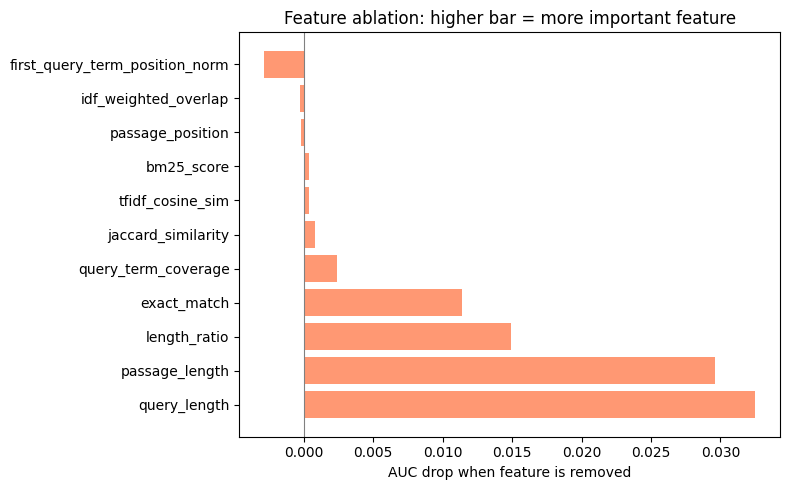

In [ ]:
# Plot feature ablation: accuracy drop when feature is removed
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ablation_df["dropped_feature"], perm_df["auc_drop"], color="coral", alpha=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("AUC drop when feature is removed")
ax.set_title("Feature ablation: higher bar = more important feature")
plt.tight_layout()
plt.show()

### 4.3 Permutation importance

Shuffle each feature one at a time and measure drop in AUC / increase in log-loss. Larger drop ⇒ more important feature. Results and plots below.

In [85]:
perm_results = []

for feature in FEATURE_COLS:
    print(f"Permuting {feature}...")
    
    # Copy validation input
    val_input_perm = {k: v.copy() for k, v in val_input_full.items()}
    
    # Shuffle ONLY this feature
    shuffled = val_input_perm[feature].copy()
    np.random.shuffle(shuffled)
    val_input_perm[feature] = shuffled
    
    # Predict with shuffled feature
    pred_perm = m_full.predict(val_input_perm, batch_size=256).flatten()
    
    auc_perm = roc_auc_score(y_val, pred_perm)
    logloss_perm = log_loss(y_val, pred_perm)
    
    perm_results.append({
        "feature": feature,
        "auc_drop": baseline_auc - auc_perm,
        "logloss_increase": logloss_perm - baseline_logloss,
        "mean_abs_pred_diff": np.mean(np.abs(pred_full - pred_perm))
    })

perm_df = pd.DataFrame(perm_results).sort_values("auc_drop", ascending=False)

print("\nPermutation Importance Results:")
print(perm_df.to_string(index=False))

Permuting query_length...
Permuting passage_length...
Permuting length_ratio...
Permuting exact_match...
Permuting query_term_coverage...
Permuting jaccard_similarity...
Permuting tfidf_cosine_sim...
Permuting bm25_score...
Permuting passage_position...
Permuting idf_weighted_overlap...
Permuting first_query_term_position_norm...

Permutation Importance Results:
                       feature  auc_drop  logloss_increase  mean_abs_pred_diff
first_query_term_position_norm  0.032298          0.006716            0.018589
              tfidf_cosine_sim  0.025147          0.006197            0.023471
              passage_position  0.016804          0.003954            0.019163
           query_term_coverage  0.007903          0.001922            0.015866
          idf_weighted_overlap  0.004543          0.000913            0.009978
                    bm25_score  0.001944          0.000407            0.005123
                   exact_match  0.000394          0.000104            0.000295
   

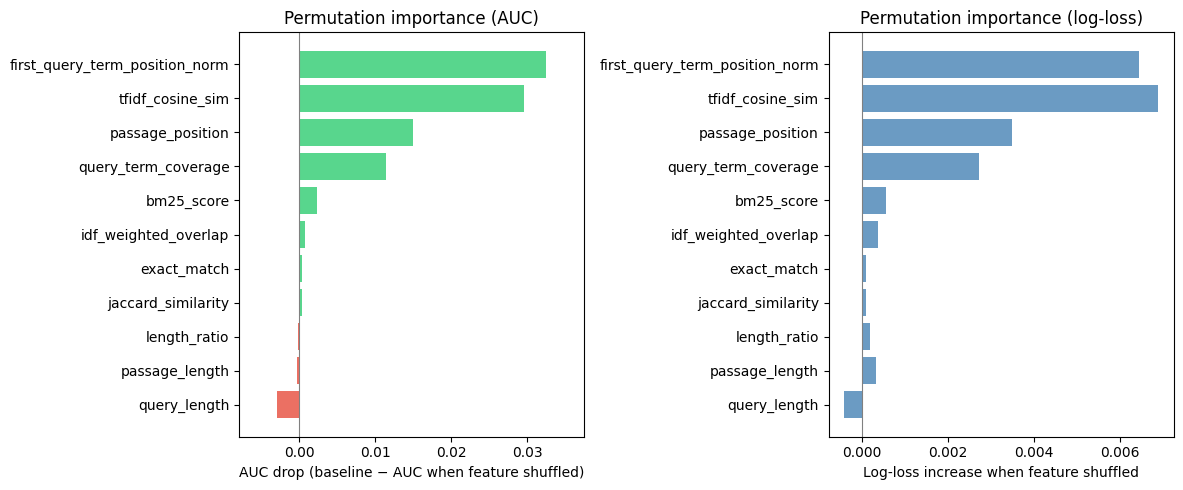

In [ ]:
# Visualize permutation importance (from cell above)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sort by auc_drop for display (ascending so most important at top)
perm_sorted = perm_df.sort_values("auc_drop", ascending=True)

# 1. AUC drop (main permutation importance metric)
ax = axes[0]
colors = ["#2ecc71" if x > 0 else "#e74c3c" for x in perm_sorted["auc_drop"]]
ax.barh(perm_sorted["feature"], perm_sorted["auc_drop"], color=colors, alpha=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("AUC drop (baseline − AUC when feature shuffled)")
ax.set_title("Permutation importance (AUC)")
x_margin = 0.005
ax.set_xlim(left=min(perm_sorted["auc_drop"].min(), 0) - x_margin,
            right=perm_sorted["auc_drop"].max() + x_margin)

# 2. Log-loss increase when feature is shuffled
ax2 = axes[1]
ax2.barh(perm_sorted["feature"], perm_sorted["logloss_increase"], color="steelblue", alpha=0.8)
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.set_xlabel("Log-loss increase when feature shuffled")
ax2.set_title("Permutation importance (log-loss)")
plt.tight_layout()
plt.show()

based on the permutation analysis, both of the new features contribute to the model. shuffling them leads to drops in AUC and Log-loss 

### 4.4 Stabilized permutation importance (repeated runs)

Repeat permutation for each feature multiple times and report mean ± std AUC drop to reduce noise.

In [ ]:
# stabilized version 
N_REPEATS = 5

for feature in FEATURE_COLS:
    auc_drops = []
    
    for _ in range(N_REPEATS):
        val_input_perm = {k: v.copy() for k, v in val_input_full.items()}
        shuffled = val_input_perm[feature].copy()
        np.random.shuffle(shuffled)
        val_input_perm[feature] = shuffled
        
        pred_perm = m_full.predict(val_input_perm, batch_size=256).flatten()
        auc_perm = roc_auc_score(y_val, pred_perm)
        auc_drops.append(baseline_auc - auc_perm)
    
    print(feature, np.mean(auc_drops), np.std(auc_drops))

query_length -0.0006766743052682323 0.00027394022560093883
passage_length -0.0005356624455993275 0.0005774186690433155
length_ratio -0.0011504029944829908 0.001317863318292967
exact_match 0.00039801963114309834 0.00013014562914178746
query_term_coverage 0.007187637556226844 0.002134621518635334
jaccard_similarity 0.00024068207107490468 0.0001414148183721611
tfidf_cosine_sim 0.03156598574169689 0.002243527372596483
bm25_score 0.0014547190877507222 0.0007086269949552116
passage_position 0.014514759881535565 0.004786461409344858
idf_weighted_overlap 0.0026313187702418526 0.0013956843323511211
first_query_term_position_norm 0.02756954244587646 0.00455180269887022


## Removing unhelpful features 

In [86]:
# All 11 features are dense (one dimension each)
Helpful_FEATURE_COLS = [
    #"query_length", "passage_length", "length_ratio", 
    "exact_match", "query_term_coverage", "jaccard_similarity",
    "tfidf_cosine_sim", "bm25_score", "passage_position",
    "idf_weighted_overlap", "first_query_term_position_norm",
]
dense_feature_columns = [DenseFeat(feat, 1) for feat in Helpful_FEATURE_COLS]
linear_feature_columns = dense_feature_columns
dnn_feature_columns = dense_feature_columns

feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Model input: dict of feature name -> array
train_model_input = {name: train_df[name].values for name in feature_names}
val_model_input = {name: val_df[name].values for name in feature_names}
test_model_input = {name: test_df[name].values for name in feature_names}

y_train = train_df[TARGET].values
y_val = val_df[TARGET].values
y_test = test_df[TARGET].values

# Device and model
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task="binary",
    device=device,
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])


# Train with explicit val set (avoids 'y_true contains only one label' when validation_split hits all-negative slice)
history = model.fit(
    train_model_input,
    y_train,
    batch_size=256,
    epochs=10,
    verbose=2,
    validation_data=(val_model_input, y_val),
)


# Predict on validation and test sets
val_pred = model.predict(val_model_input, batch_size=256)
test_pred = model.predict(test_model_input, batch_size=256)

for name, y, pred, qids in [("Val", y_val, val_pred, val_df["query_id"].values), ("Test", y_test, test_pred, test_df["query_id"].values)]:
    pred_binary = (pred >= 0.5).astype(int).flatten()
    acc = (pred_binary == y).mean()
    auc = roc_auc_score(y, pred)
    logloss = log_loss(y, pred)
    mrr = mrr_at_k(y, pred, qids, k=10)
    ndcg = ndcg_at_k(y, pred, qids, k=10)
    print(f"{name} accuracy: {acc:.4f}  (pred mean: {pred.mean():4f})")
    print(f"{name} auc: {auc:.4f}  (logloss: {logloss:.4f})")
    print(f"{name} MRR@10: {mrr:.4f}  NDCG@10: {ndcg:.4f}")

Using device: cpu
cpu
Train on 37986 samples, validate on 8149 samples, 149 steps per epoch
Epoch 1/10
0s - loss:  0.3598 - binary_crossentropy:  0.3593 - val_binary_crossentropy:  0.3261
Epoch 2/10
0s - loss:  0.3226 - binary_crossentropy:  0.3226 - val_binary_crossentropy:  0.3223
Epoch 3/10
0s - loss:  0.3208 - binary_crossentropy:  0.3206 - val_binary_crossentropy:  0.3222
Epoch 4/10
1s - loss:  0.3204 - binary_crossentropy:  0.3207 - val_binary_crossentropy:  0.3215
Epoch 5/10
0s - loss:  0.3202 - binary_crossentropy:  0.3199 - val_binary_crossentropy:  0.3215
Epoch 6/10
0s - loss:  0.3203 - binary_crossentropy:  0.3202 - val_binary_crossentropy:  0.3215
Epoch 7/10
0s - loss:  0.3200 - binary_crossentropy:  0.3200 - val_binary_crossentropy:  0.3218
Epoch 8/10
0s - loss:  0.3198 - binary_crossentropy:  0.3198 - val_binary_crossentropy:  0.3232
Epoch 9/10
0s - loss:  0.3198 - binary_crossentropy:  0.3194 - val_binary_crossentropy:  0.3218
Epoch 10/10
1s - loss:  0.3198 - binary_cros

## Addressing Class Imbalance via Oversampling
- doesn't make a huge difference 

In [87]:
# Address class imbalance via oversampling (deepctr_torch fit() does not support sample_weight)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

Helpful_FEATURE_COLS = [
    "exact_match", "query_term_coverage", "jaccard_similarity",
    "tfidf_cosine_sim", "bm25_score", "passage_position",
    "idf_weighted_overlap", "first_query_term_position_norm",
]
dense_feature_columns = [DenseFeat(feat, 1) for feat in Helpful_FEATURE_COLS]
linear_feature_columns = dense_feature_columns
dnn_feature_columns = dense_feature_columns

feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Oversample positives so the model sees more relevant (label=1) examples
train_pos = train_df[train_df[TARGET] == 1]
train_neg = train_df[train_df[TARGET] == 0]
n_pos, n_neg = len(train_pos), len(train_neg)
# Repeat positives to get ~1:3 pos:neg ratio (tune repeat_factor if needed)
repeat_factor = max(1, (n_neg // 3) // max(1, n_pos))
train_pos_rep = pd.concat([train_pos] * repeat_factor, ignore_index=True)
train_balanced = pd.concat([train_neg, train_pos_rep], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Original train: {n_neg} neg, {n_pos} pos. After oversampling: {len(train_balanced)} rows ({len(train_balanced[train_balanced[TARGET]==0])} neg, {len(train_balanced[train_balanced[TARGET]==1])} pos)")

# Model inputs from balanced training data; val/test unchanged
train_model_input = {name: train_balanced[name].values for name in feature_names}
val_model_input = {name: val_df[name].values for name in feature_names}
test_model_input = {name: test_df[name].values for name in feature_names}

y_train = train_balanced[TARGET].values
y_val = val_df[TARGET].values
y_test = test_df[TARGET].values

# Device and model
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task="binary",
    device=device,
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["binary_crossentropy"])

# Train (no sample_weight; imbalance addressed by oversampling)
history = model.fit(
    train_model_input,
    y_train,
    batch_size=256,
    epochs=10,
    verbose=2,
    validation_data=(val_model_input, y_val),
)


# Predict on validation and test sets
val_pred = model.predict(val_model_input, batch_size=256)
test_pred = model.predict(test_model_input, batch_size=256)

for name, y, pred, qids in [("Val", y_val, val_pred, val_df["query_id"].values), ("Test", y_test, test_pred, test_df["query_id"].values)]:
    pred_binary = (pred >= 0.5).astype(int).flatten()
    acc = (pred_binary == y).mean()
    auc = roc_auc_score(y, pred)
    logloss = log_loss(y, pred)
    mrr = mrr_at_k(y, pred, qids, k=10)
    ndcg = ndcg_at_k(y, pred, qids, k=10)
    print(f"{name} accuracy: {acc:.4f}  (pred mean: {pred.mean():4f})")
    print(f"{name} auc: {auc:.4f}  (logloss: {logloss:.4f})")
    print(f"{name} MRR@10: {mrr:.4f}  NDCG@10: {ndcg:.4f}")

Original train: 33925 neg, 4061 pos. After oversampling: 42047 rows (33925 neg, 8122 pos)
Using device: cpu
cpu
Train on 42047 samples, validate on 8149 samples, 165 steps per epoch
Epoch 1/10
1s - loss:  0.4855 - binary_crossentropy:  0.4860 - val_binary_crossentropy:  0.3517
Epoch 2/10
1s - loss:  0.4604 - binary_crossentropy:  0.4602 - val_binary_crossentropy:  0.3457
Epoch 3/10
0s - loss:  0.4590 - binary_crossentropy:  0.4591 - val_binary_crossentropy:  0.3444
Epoch 4/10
0s - loss:  0.4587 - binary_crossentropy:  0.4587 - val_binary_crossentropy:  0.3423
Epoch 5/10
0s - loss:  0.4584 - binary_crossentropy:  0.4582 - val_binary_crossentropy:  0.3567
Epoch 6/10
0s - loss:  0.4579 - binary_crossentropy:  0.4575 - val_binary_crossentropy:  0.3489
Epoch 7/10
0s - loss:  0.4581 - binary_crossentropy:  0.4578 - val_binary_crossentropy:  0.3539
Epoch 8/10
0s - loss:  0.4579 - binary_crossentropy:  0.4575 - val_binary_crossentropy:  0.3511
Epoch 9/10
0s - loss:  0.4579 - binary_crossentrop